# **Исследование методов эффективного применения адаптеров (LoRA)  для дообучения моделей в условиях ограниченных вычислительных ресурсов**

**Содержание работы:**
1. EDA (самостоятельно собранные данные (fontanka.ru и dp.ru))
2. Эксперименты с моделью Qwen3-0.6B:
- Эксперимент 1 - LoRA
  - эксперимент проводится для датасета в объеме 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 2 - QLoRA
  - эксперимент проводится для датасета в объеме 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 3 - OrthoGeoLoRA
  - эксперимент проводится для датасета в объеме 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

# Настройка окружения и инициализация

In [ ]:
!pip install transformers accelerate peft datasets evaluate bitsandbytes

In [ ]:
%pip -q install "transformers>=4.43" "datasets>=2.18" "accelerate>=0.33" "trl>=0.9" "bitsandbytes>=0.45"

import os, random, math, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    DataCollatorForLanguageModeling
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.is_available())

MODEL_NAME = "Qwen/Qwen3-0.6B"

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print("device:", device, "| dtype:", DTYPE)

Note: you may need to restart the kernel to use updated packages.
True
device: cuda | dtype: torch.bfloat16


In [ ]:
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score
import evaluate

# **EDA (заголовки с fontanka.ru и dp.ru)**

- Загрузка датасета - самостоятельно собранные заголовки с сайтов fontanka.ru и dp.ru
- EDA (размеры, классы, длины, графики)

In [ ]:
# Загрузка датасета
ds = pd.read_csv('result.csv')

In [ ]:
ds

,text,label
0,Петербург и Ленобласть в этом году отремонтиру...,auto
1,Прямое железнодорожное сообщение свяжет Мурман...,auto
2,Поддать газу. Hyundai в следующем году начнет ...,auto
3,"Двое водителей не поделили проспект Науки, и о...",auto
4,Литий-ионные батареи для российских электромоб...,auto
...,...,...
41055,КХЛ отменила регулярный чемпионат,sport
41056,В Петербурге появился третий профессиональный ...,sport
41057,Российский гонщик отметил победу в Португалии ...,sport
41058,Защитник «Зенита» против лимита: меньше иностр...,sport


Список колонок:
['text', 'label']

Размер датасета:
(41060, 2)

Три случайных примера:

Пример 7296:
Text: Дзюба — о будущем: «Акрон» в приоритете, но всё решится позже
Label: sport

Пример 1639:
Text: За октябрь инспекторы ГАИ выявили в Петербурге и Ленобласти более 800 случаев вождения в нетрезвом состоянии, сообщили в пресс-службе региональной Госавтоинспекции.
Label: auto

Пример 18024:
Text: В январе-сентябре 2019 года операционная прибыль филиала Альфа-Банка в Петербурге составила 10,9 млрд рублей, что на 37% больше показателя за аналогичный период прошлого года. Об этом сообщает пресс-служба кредитной организации.
Label: finances

Train size: 32848
Test size:  8212

Columns: ['text', 'label']

Class distribution (train):
label
realty      8212
sport       8212
finances    8212
auto        8212
Name: count, dtype: int64

Class distribution (test):
label
realty      2053
auto        2053
finances    2053
sport       2053
Name: count, dtype: int64

Average text length (train): 107.

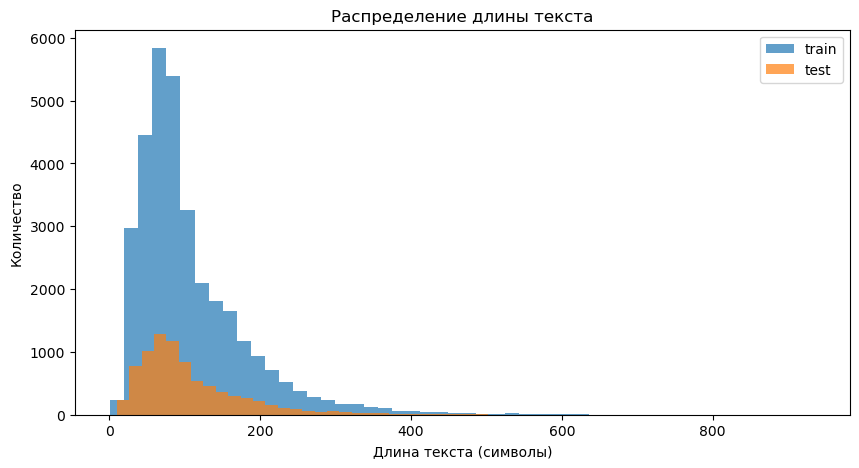

In [ ]:
# Делим данные
X = ds['text']
y = ds['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Объединяем обратно в DataFrame
train = pd.DataFrame({
    'text': X_train,
    'label': y_train
}).reset_index(drop=True)

test = pd.DataFrame({
    'text': X_test,
    'label': y_test
}).reset_index(drop=True)

# Основная информация
print("Список колонок:")
print(ds.columns.tolist())

print("\nРазмер датасета:")
print(ds.shape)

# Случайные примеры
print("\nТри случайных примера:")

random_indices = random.sample(range(len(train)), 3)

for idx in random_indices:
    example = train.iloc[idx]
    print(f"\nПример {idx}:")
    print(f"Text: {example['text']}")
    print(f"Label: {example['label']}")

# Статистика
df_train = train.copy()
df_test = test.copy()

print(f"\nTrain size: {len(df_train)}")
print(f"Test size:  {len(df_test)}")

print("\nColumns:", df_train.columns.tolist())

# Распределение классов
print("\nClass distribution (train):")
print(df_train['label'].value_counts())

print("\nClass distribution (test):")
print(df_test['label'].value_counts())

# Длина текста
df_train['text_len'] = df_train['text'].apply(len)
df_test['text_len'] = df_test['text'].apply(len)

print(f"\nAverage text length (train): {df_train['text_len'].mean():.1f} characters")
print(f"Average text length (test):  {df_test['text_len'].mean():.1f} characters")

print(f"Text length range (train): {df_train['text_len'].min()} - {df_train['text_len'].max()}")
print(f"Text length range (test):  {df_test['text_len'].min()} - {df_test['text_len'].max()}")

plt.figure(figsize=(10,5))
plt.hist(df_train['text_len'], bins=50, alpha=0.7, label='train')
plt.hist(df_test['text_len'], bins=50, alpha=0.7, label='test')
plt.xlabel("Длина текста (символы)")
plt.ylabel("Количество")
plt.title("Распределение длины текста")
plt.legend()
plt.show()

In [ ]:
# части датасета
# 3000 образцов в каждом классе обучающей выборки
train_3000 = (
    ds.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=3000, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_3000['label'].value_counts())
print("Размер:", train_3000.shape)

# 1500 образцов в каждом классе обучающей выборки
train_1500 = (
    ds.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=1500, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_1500['label'].value_counts())
print("Размер:", train_1500.shape)

# 300 образцов в каждом классе обучающей выборки
train_300 = (
    ds.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=300, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_300['label'].value_counts())
print("Размер:", train_300.shape)

# Подготовка токенизатора

In [ ]:
# Преобразование label в числа
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['label'] = le.fit_transform(train['label'])
test['label'] = le.transform(test['label'])

num_labels = len(le.classes_)

In [ ]:
#Подготовка токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Добавляем pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [ ]:
def prepare_dataset(train=train, test=test, sample_frac=1.0, seed=42):
    """
    Подготовка датасета:
    - pandas в HF Dataset
    - сэмплирование
    - токенизация
    - label в labels
    """

    # 1. pandas в Dataset
    train_ds = Dataset.from_pandas(train)
    test_ds = Dataset.from_pandas(test)

    # 2. Сэмплирование
    train_ds = train_ds.shuffle(seed=seed).select(
        range(int(sample_frac * len(train_ds)))
    )

    # 3. Токенизация
    train_tok = train_ds.map(tokenize, batched=True)
    test_tok = test_ds.map(tokenize, batched=True)

    # 4. Удаление лишнего
    train_tok = train_tok.remove_columns(["text"])
    test_tok = test_tok.remove_columns(["text"])

    # 5. label → labels
    train_tok = train_tok.rename_column("label", "labels")
    test_tok = test_tok.rename_column("label", "labels")

    # 6. Формат для PyTorch
    train_tok.set_format("torch")
    test_tok.set_format("torch")

    return train_tok, test_tok

# **Эксперимент 1 - Baseline**

**План эксперимента 1 - Baseline**:

- Определение функций для эксперимента
- Определение объема выборки
- Baseline-эксперимент:
  - загружается базовая модель Qwen3-0.6B
  - замораживаются все параметры, кроме классификационной головы
  - Trainer обучает 1 эпоху
  - собираются baseline-метрики

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- добавление baseline
- сохранение в lora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 1

In [ ]:
def load_base_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        torch_dtype=torch.float16,
        device_map="auto",
        ignore_mismatched_sizes=True
    )

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [ ]:
# Заморозка модели (baseline)
def freeze_all_but_head(model):
    for name, param in model.named_parameters():
        if "classifier" not in name and "score" not in name:
            param.requires_grad = False
    return model


# Подсчёт trainable параметров
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Обучение + инференс
def train_and_predict(model, train_tok, test_tok, tokenizer):
    args = TrainingArguments(
        output_dir="./outputs/baseline",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    mid = time.time()

    pred_test = trainer.predict(test_tok)
    end = time.time()

    pred_train = trainer.predict(train_tok)

    return pred_train, pred_test, mid - start, end - mid


# Подсчёт метрик
def compute_full_metrics(pred):
    logits = pred.predictions
    labels = pred.label_ids
    preds = np.argmax(logits, axis=-1)

    loss = F.cross_entropy(
        torch.tensor(logits),
        torch.tensor(labels)
    ).item()

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
        "loss": loss
    }


# GPU метрики
def get_gpu_metrics():
    if torch.cuda.is_available():
        return {
            "gpu_memory_allocated_gb": torch.cuda.max_memory_allocated() / 1024**3,
            "gpu_memory_reserved_gb": torch.cuda.max_memory_reserved() / 1024**3,
        }
    return {
        "gpu_memory_allocated_gb": 0,
        "gpu_memory_reserved_gb": 0,
    }


# функция baseline
def run_baseline(train_tok, test_tok, tokenizer):
    print("\nЗапуск Baseline (только classification head)")

    model = load_base_model()
    model = freeze_all_but_head(model)

    print(f"Trainable parameters: {count_trainable_params(model):,}")

    pred_train, pred_test, time_train, time_eval = train_and_predict(
        model, train_tok, test_tok, tokenizer
    )

    train_metrics = compute_full_metrics(pred_train)
    test_metrics = compute_full_metrics(pred_test)
    gpu_metrics = get_gpu_metrics()

    return {
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_loss": train_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_f1": test_metrics["f1"],
        "test_loss": test_metrics["loss"],
        "time_sec_train": time_train,
        "time_sec_eval": time_eval,
        **gpu_metrics
    }

### **8212 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [ ]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.589316,0.560547,0.798831,0.798213


{'train_accuracy': 0.7931989771066732,
 'train_f1': 0.7926897806581239,
 'train_loss': 0.568359375,
 'test_accuracy': 0.7988309790550414,
 'test_f1': 0.7982128692362062,
 'test_loss': 0.5615234375,
 'time_sec_train': 357.6903395652771,
 'time_sec_eval': 67.80096769332886,
 'gpu_memory_allocated_gb': 1.2894277572631836,
 'gpu_memory_reserved_gb': 1.30078125}

In [ ]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_DP_baseline_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_baseline_100pct.csv")


Результаты сохранены в qw3_PD_baseline_100pct.csv


### **3000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

In [ ]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.590907,0.454834,0.868553,0.868672


{'train_accuracy': 0.8706166666666667,
 'train_f1': 0.8705726548118541,
 'train_loss': 0.45263671875,
 'test_accuracy': 0.8685526315789474,
 'test_f1': 0.8686720332777497,
 'test_loss': 0.455078125,
 'time_sec_train': 592.1738736629486,
 'time_sec_eval': 63.150731563568115,
 'gpu_memory_allocated_gb': 1.2898826599121094,
 'gpu_memory_reserved_gb': 1.30078125}

In [ ]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_baseline_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_baseline_50pct.csv")


Результаты сохранены в qw3_baseline_50pct.csv


### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.286369,0.412842,0.853816,0.853451


{'train_accuracy': 0.8543333333333333,
 'train_f1': 0.8537582784171075,
 'train_loss': 0.41259765625,
 'test_accuracy': 0.8538157894736842,
 'test_f1': 0.8534510180894366,
 'test_loss': 0.412841796875,
 'time_sec_train': 170.79531860351562,
 'time_sec_eval': 63.23573064804077,
 'gpu_memory_allocated_gb': 1.2890777587890625,
 'gpu_memory_reserved_gb': 1.30078125}

In [ ]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_baseline_10pct.csv", index=False)
print("\nРезультаты сохранены в qw3_baseline_10pct.csv")


Результаты сохранены в qw3_baseline_10pct.csv


### **300 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_300)

In [ ]:
# Baseline: только classification head
print("\nЗапуск Baseline (только classification head)")
base_model = load_base_model()
# Замораживаем все слои кроме классификационной головы
for name, param in base_model.named_parameters():
    if "classifier" not in name and "score" not in name:
        param.requires_grad = False

print(f"Trainable parameters in baseline: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters in baseline: 6,144


# **Эксперимент 2 - LoRA**

**План эксперимента 2 - LoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в lora_results.csv
- вывод сводной таблицы


Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 2

In [ ]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = create_lora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.235524,0.398438,0.904286,0.904119


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.298094,0.326660,0.917925,0.917748


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1199.9614126682281, 'time_sec_eval': 97.51859641075134, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.5700907707214355, 'gpu_memory_reserved_gb': 3.603515625, 'trainable_parameters': 9179136, 'train_accuracy': 0.9392352654651729, 'train_f1': 0.9391731811794216, 'train_loss': 0.232666015625, 'test_accuracy': 0.9179249878226985, 'test_f1': 0.9177476695744007, 'test_loss': 0.32666015625}


**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_PD_lora_results_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_lora_results_100pct.csv")
df_results


Результаты сохранены в qw3_PD_lora_results_100pct.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,979.729035,79.855940,4,q_proj-v_proj,3.047973,3.115234,577536,0.912171,0.912018,0.356689,0.904286,0.904119,0.398438
1,1065.443275,86.512799,4,q_proj-k_proj-v_proj,3.190670,3.261719,806912,0.914302,0.914258,0.347656,0.904530,0.904445,0.386719
2,1167.488127,91.810446,4,q_proj-k_proj-v_proj-o_proj,3.468406,3.500000,1150976,0.917864,0.917792,0.326416,0.909523,0.909360,0.370117
3,978.114989,79.254240,8,q_proj-v_proj,3.055236,3.123047,1150976,0.916403,0.916282,0.330322,0.907453,0.907257,0.379639
4,1061.259833,85.794758,8,q_proj-k_proj-v_proj,3.200923,3.271484,1609728,0.921091,0.921053,0.319824,0.909766,0.909612,0.376221
5,1165.038853,91.612385,8,q_proj-k_proj-v_proj-o_proj,3.482933,3.515625,2297856,0.923039,0.922990,0.297119,0.911349,0.911201,0.358398
6,978.807645,80.050011,16,q_proj-v_proj,3.069763,3.136719,2297856,0.922948,0.922872,0.302979,0.910862,0.910665,0.361816
7,1059.442078,85.718138,16,q_proj-k_proj-v_proj,3.221431,3.292969,3215360,0.926997,0.926961,0.291748,0.912323,0.912174,0.363037
8,1152.219990,91.587477,16,q_proj-k_proj-v_proj-o_proj,3.511985,3.544922,4591616,0.930802,0.930711,0.263916,0.915490,0.915258,0.345703
9,996.624528,81.713864,32,q_proj-v_proj,3.098815,3.166016,4591616,0.929006,0.928942,0.265381,0.913298,0.913118,0.340332


### **3000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.333075,0.322021,0.932763,0.932655


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.332464,0.267578,0.938553,0.938506


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 2154.602918624878, 'time_sec_eval': 91.41540193557739, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.5700907707214355, 'gpu_memory_reserved_gb': 3.603515625, 'trainable_parameters': 9179136, 'train_accuracy': 0.95545, 'train_f1': 0.9554539577676802, 'train_loss': 0.18798828125, 'test_accuracy': 0.9385526315789474, 'test_f1': 0.9385061461625318, 'test_loss': 0.267578125}


**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_50pct.csv")
df_results


Результаты сохранены в qw3_lora_results_50pct.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,1717.694490,73.957769,4,q_proj-v_proj,3.047973,3.115234,577536,0.941950,0.941926,0.264404,0.932763,0.932655,0.321777
1,1882.360325,79.809637,4,q_proj-k_proj-v_proj,3.190670,3.261719,806912,0.942050,0.941994,0.260010,0.931447,0.931353,0.326904
2,2071.888630,85.238154,4,q_proj-k_proj-v_proj-o_proj,3.468406,3.500000,1150976,0.943683,0.943645,0.245972,0.933026,0.932963,0.306152
3,1730.551083,73.667501,8,q_proj-v_proj,3.055236,3.123047,1150976,0.943117,0.943077,0.249756,0.932368,0.932279,0.312988
4,1883.087394,79.781075,8,q_proj-k_proj-v_proj,3.200923,3.271484,1609728,0.944667,0.944633,0.249634,0.933026,0.932946,0.318848
5,2065.172867,84.679115,8,q_proj-k_proj-v_proj-o_proj,3.482933,3.515625,2297856,0.946450,0.946432,0.229126,0.933158,0.933086,0.300537
6,1732.198115,74.374524,16,q_proj-v_proj,3.069763,3.136719,2297856,0.945267,0.945235,0.233765,0.934868,0.934778,0.301514
7,1890.082283,80.297134,16,q_proj-k_proj-v_proj,3.221431,3.292969,3215360,0.949533,0.949527,0.220947,0.935132,0.935061,0.298340
8,2060.645402,85.701296,16,q_proj-k_proj-v_proj-o_proj,3.511985,3.544922,4591616,0.950983,0.950966,0.206909,0.935789,0.935707,0.282715
9,1775.243100,76.638788,32,q_proj-v_proj,3.098815,3.166016,4591616,0.950233,0.950223,0.217896,0.935658,0.935604,0.291504


### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_1500)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.387709,0.355469,0.923947,0.923774


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 493.50045943260193, 'time_sec_eval': 89.88799095153809, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.5700907707214355, 'gpu_memory_reserved_gb': 3.603515625, 'trainable_parameters': 9179136, 'train_accuracy': 0.9451666666666667, 'train_f1': 0.9451114816400553, 'train_loss': 0.232666015625, 'test_accuracy': 0.9239473684210526, 'test_f1': 0.9237744352622604, 'test_loss': 0.355712890625}


**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_10pct_new.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_10pct.csv")
df_results

### **300 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_300)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 550,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,23.503125,25.140625,0.868553,0.868485


...

Trainable parameters: 8,722,432


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,5.974218,6.539062,0.892632,0.891978


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 309.84600162506104, 'time_sec_eval': 103.31073045730591, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 9.034234523773193, 'gpu_memory_reserved_gb': 9.126953125, 'trainable_parameters': 8722432, 'train_accuracy': 0.9068333333333334, 'train_f1': 0.9064859083996992, 'train_loss': 4.59765625, 'test_accuracy': 0.8926315789473684, 'test_f1': 0.8919775378694192, 'test_loss': 4.59765625}


**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("lora_results_5pct_new.csv", index=False)
print("\nРезультаты сохранены в lora_results_5pct.csv")
df_results


Результаты сохранены в lora_results_5pct.csv


,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss,time_sec_train,time_sec_eval,gpu_memory_allocated_gb,gpu_memory_reserved_gb,rank,modules,trainable_parameters
0,0.822500,0.821957,0.505859,0.815263,0.814705,0.522461,140.418670,77.093895,6.158684,6.246094,NaN,NaN,NaN
1,0.890000,0.889953,inf,0.868553,0.868485,inf,254.474691,86.355149,8.532959,8.632812,4.0,q_proj-v_proj,550912.0
2,0.867333,0.866904,0.413086,0.863289,0.862928,0.413086,270.947544,89.913077,8.734329,8.814453,4.0,q_proj-k_proj-v_proj,751616.0
3,0.913333,0.913099,inf,0.885395,0.885112,inf,291.912743,95.289309,8.947952,9.017578,4.0,q_proj-k_proj-v_proj-o_proj,1095680.0
4,0.890333,0.890272,0.399658,0.886579,0.886278,0.399658,255.381765,86.314413,8.535843,8.638672,8.0,q_proj-v_proj,1095680.0
5,0.898667,0.898428,0.369385,0.897895,0.897564,0.369385,270.978379,89.973168,8.738388,8.824219,8.0,q_proj-k_proj-v_proj,1497088.0
6,0.914167,0.913904,0.357422,0.909605,0.909233,0.357422,292.482302,95.165277,8.953720,9.031250,8.0,q_proj-k_proj-v_proj-o_proj,2185216.0
7,0.911667,0.911414,0.345947,0.913421,0.913071,0.345947,256.139744,86.894918,8.541611,8.654297,16.0,q_proj-v_proj,2185216.0
8,0.914667,0.914511,0.350586,0.908026,0.907656,0.350586,271.826710,90.658551,8.747221,8.845703,16.0,q_proj-k_proj-v_proj,2988032.0
9,0.905667,0.905724,5.660156,0.887500,0.887597,5.660156,293.185621,96.269598,8.978693,9.060547,16.0,q_proj-k_proj-v_proj-o_proj,4364288.0


# Эксперимент 3 - QLoRA

**План эксперимента 3 - QLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]
  - Методы квантизации
    - NF4
    - FP4

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в qlora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 3

In [ ]:
# Функция создания модели с QLoRA

def create_qlora_model(rank, target_modules, quant_type="nf4"):
    """
    Создает модель с 4-битным квантованием и LoRA адаптерами

    Args:
        rank: ранг LoRA
        target_modules: список модулей для адаптации
        quant_type: тип квантования ("nf4" или "fp4")
    """

    # Конфигурация квантования
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type=quant_type,  # "nf4" или "fp4"
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    # Загружаем базовую модель с квантованием
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        trust_remote_code=True
    )

    # Конфигурация LoRA
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.SEQ_CLS
    )

    # Оборачиваем модель в LoRA
    model = get_peft_model(base_model, lora_config)

    return model

In [ ]:
# Функция для вычисления метрик

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [ ]:
# Функция для запуска эксперимента

def run_experiment(rank, target_modules, quant_type="nf4", output_dir="./qlora_outputs"):
    """
    Запускает один эксперимент QLoRA

    Args:
        rank: ранг LoRA
        target_modules: список модулей
        quant_type: тип квантования ("nf4" или "fp4")
        output_dir: директория для сохранения

    Returns:
        dict: метрики эксперимента
    """

    # Создаем уникальное имя для эксперимента
    modules_str = "-".join(target_modules)
    exp_name = f"qlora_{quant_type}_r{rank}_{modules_str}"

    print(f"\n{'='*60}")
    print(f"Запуск: {exp_name}")
    print(f"{'='*60}")

    metrics = {}

    # Создаем модель
    try:
        model = create_qlora_model(rank, target_modules, quant_type)
        trainable_params = model.num_parameters(only_trainable=True)
        print(f"Trainable parameters: {trainable_params:,}")
    except Exception as e:
        print(f"Ошибка при создании модели: {e}")
        return None

    # Аргументы для тренировки
    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{exp_name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=False,
        bf16=True,
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{exp_name}/logs"
    )

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.337461,0.424699,0.900755,0.900555


...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 3,215,360


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_PD_qlora_results_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_100pct.csv")


Результаты сохранены в qw3_PD_qlora_results_100pct_nf4_1.csv


### **3000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_3000)

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.443144,0.283098,0.938158,0.938106


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 2421.961044073105, 'time_sec_eval': 108.55057311058044, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 2.72062349319458, 'gpu_memory_reserved_gb': 2.7578125, 'trainable_parameters': 9179136, 'train_accuracy': 0.95535, 'train_f1': 0.9553543170221979, 'train_loss': 0.19653765857219696, 'test_accuracy': 0.9381578947368421, 'test_f1': 0.9381055752962347, 'test_loss': 0.2830360233783722}


In [ ]:
# Создаем DataFrame
df_qlora_results_50pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_50pct.to_csv("qw3_qlora_results_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_50pct.csv")


Результаты сохранены в qw3_qlora_results_50pct.csv


### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.358788,0.406644,0.911842,0.911525


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.386197,0.374278,0.920789,0.920584


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 565.7552809715271, 'time_sec_eval': 107.71781253814697, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 2.71574068069458, 'gpu_memory_reserved_gb': 2.74609375, 'trainable_parameters': 9179136, 'train_accuracy': 0.9425833333333333, 'train_f1': 0.9424919254973095, 'train_loss': 0.2428663671016693, 'test_accuracy': 0.9207894736842105, 'test_f1': 0.9205838609288873, 'test_loss': 0.3741348087787628}


In [ ]:
# Создаем DataFrame
df_qlora_results_10pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_10pct.to_csv("qw3_qlora_results_10pct.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_10pct.csv")


Результаты сохранены в qw3_qlora_results_10pct.csv


### **300 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_300)

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.459120,0.476238,0.889342,0.888985


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.333989,0.382768,0.915921,0.915796


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 335.6133608818054, 'time_sec_eval': 107.41850924491882, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.239992618560791, 'gpu_memory_reserved_gb': 3.3046875, 'trainable_parameters': 9179136, 'train_accuracy': 0.9385, 'train_f1': 0.938456044443588, 'train_loss': 0.24800482392311096, 'test_accuracy': 0.915921052631579, 'test_f1': 0.9157963839750133, 'test_loss': 0.38267782330513}


In [ ]:
# Создаем DataFrame
df_qlora_results_5pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_5pct.to_csv("qw3_qlora_results_5pct.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_5pct.csv")


Результаты сохранены в qw3_qlora_results_5pct.csv


# Эксперимент 4 - OrthoGeoLoRA

**План эксперимента 4 - OrthoGeoLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в oglora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки 8212 / 3000 / 1500 / 300 %

### Функции для эксперимента 4

In [ ]:
class OrthogonalizationLayer(nn.Module):
    def __init__(self, in_dim, rank, dtype):
        super().__init__()
        self.theta = nn.Parameter(torch.randn(in_dim, rank, dtype=torch.float32) * 0.01)

    def forward(self):
        q, r = torch.linalg.qr(self.theta, mode="reduced")
        sign = torch.sign(torch.diag(r))
        q = q * sign.unsqueeze(0)
        return q

In [ ]:
class OrthoGeoLoRALayer(nn.Module):
    def __init__(self, base_lora_layer):
        super().__init__()

        self.base_layer = base_lora_layer.base_layer

        if isinstance(base_lora_layer.r, dict):
            self.rank = list(base_lora_layer.r.values())[0]
        else:
            self.rank = base_lora_layer.r

        if isinstance(base_lora_layer.scaling, dict):
            self.scaling = list(base_lora_layer.scaling.values())[0]
        else:
            self.scaling = base_lora_layer.scaling

        in_features = self.base_layer.in_features
        out_features = self.base_layer.out_features

        dtype = self.base_layer.weight.dtype

        self.A_orth = OrthogonalizationLayer(in_features, self.rank, dtype)
        self.B_orth = OrthogonalizationLayer(out_features, self.rank, dtype)

        self.log_singular = nn.Parameter(torch.zeros(self.rank, dtype=dtype))

    @property
    def singular(self):
        return F.softplus(self.log_singular) + 1e-6

    def forward(self, x):

        base = self.base_layer(x)

        A = self.A_orth().to(x.dtype)
        B = self.B_orth().to(x.dtype)
        S = self.singular.to(x.dtype)

        xA = torch.matmul(x, A)
        xS = xA * S.unsqueeze(0)
        update = torch.matmul(xS, B.T)

        return base + update * self.scaling

In [ ]:
def convert_lora_to_orthogeolora(model):

    for name, module in list(model.named_modules()):

        if hasattr(module, "lora_A") and hasattr(module, "lora_B"):

            parent = model
            path = name.split(".")
            for p in path[:-1]:
                parent = getattr(parent, p)

            lora_layer = getattr(parent, path[-1])

            ortho_layer = OrthoGeoLoRALayer(lora_layer)

            setattr(parent, path[-1], ortho_layer)

    return model

In [ ]:
def create_orthogeolora_model(rank, target_modules):

    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )

    model = get_peft_model(base, lora_cfg)

    model = convert_lora_to_orthogeolora(model)

    return model

In [ ]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment_oglora(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = None
    trainer = None

    model = create_orthogeolora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'], seed=42 ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 551,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.334192,0.417725,0.922105,0.921890


...

{'time_sec': 1334.621170759201, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'seed': 44, 'gpu_memory_allocated_gb': 12.157640933990479, 'gpu_memory_reserved_gb': 12.21484375, 'trainable_parameters': 8726016, 'train_accuracy': 0.25075, 'train_f1': 0.10054057565460725, 'train_loss': nan, 'test_accuracy': 0.25, 'test_f1': 0.1, 'test_loss': nan}

=== Запуск LoRA r=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'], seed=46 ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 8,726,016


Epoch,Training Loss,Validation Loss


In [ ]:
# Создаем DataFrame
df_oglora_results_100pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_100pct.to_csv("oglora_results_100pct.csv", index=False)
print("\nРезультаты сохранены в oglora_results_100pct.csv")

### **3000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_3000)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,760


...

Trainable parameters: 9,182,720


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.394168,0.348145,0.933684,0.933627


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 5151.40330862999, 'time_sec_eval': 3625.5325157642365, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.027678966522217, 'gpu_memory_reserved_gb': 3.060546875, 'trainable_parameters': 9182720, 'train_accuracy': 0.9456666666666667, 'train_f1': 0.9456568642313075, 'train_loss': 0.272705078125, 'test_accuracy': 0.9336842105263158, 'test_f1': 0.933627226762695, 'test_loss': 0.347900390625}


In [ ]:
# Создаем DataFrame
df_oglora_results_50pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_50pct.to_csv("qw3_oglora_results_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_oglora_results_50pct.csv")


Результаты сохранены в qw3_oglora_results_50pct.csv


### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_1500)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame
df_oglora_results_10pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_10pct.to_csv("qw3_oglora_results_10pct.csv", index=False)
print("\nРезультаты сохранены в qw3_oglora_results_10pct.csv")
df_oglora_results_10pct

### **300 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_300)

In [ ]:
# OGLoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,760


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.412230,0.426758,0.908684,0.908509


...

Trainable parameters: 9,182,720


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.497807,0.628906,0.906579,0.906403


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 885.2767939567566, 'time_sec_eval': 737.9789996147156, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.555105686187744, 'gpu_memory_reserved_gb': 3.58984375, 'trainable_parameters': 9182720, 'train_accuracy': 0.935, 'train_f1': 0.9349207474869952, 'train_loss': 0.38525390625, 'test_accuracy': 0.906578947368421, 'test_f1': 0.9064033386274469, 'test_loss': 0.62841796875}


In [ ]:
# Создаем DataFrame
df_oglora_results_5pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_5pct.to_csv("wq3_oglora_results_5pct.csv", index=False)
print("\nРезультаты сохранены в qw3_oglora_results_5pct.csv")


Результаты сохранены в qw3_oglora_results_5pct.csv
